In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
df = pd.read_csv(r"C:\Users\HP\Desktop\RealEstatePricePrediction\data\raw\Bengaluru_House_Data.csv")

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
print(df.shape)

(13320, 9)


- 13,320 rows & 9 columns
- good amount of data for machine learning model

In [5]:
print(df.dtypes)

area_type           str
availability        str
location            str
size                str
society             str
total_sqft          str
bath            float64
balcony         float64
price           float64
dtype: object


In [6]:
print(df.isnull().sum())

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


- 5502 missing values in society column almost 41%, i'll drop this column
- balcony has 609 missing, drop
- bath has 73 missing, drop
- size has 16 and location has 1 misiing i'll drop these as well

In [7]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


- avg price is 112.5 lakhs, max is 3600 lakhs, clearly an oulier
- max bathrooms is 40, outlier

In [8]:
print("Unique locations:", df["location"].nunique())
print("Unique area types:", df["area_type"].nunique())
print("Unique sizes:", df["size"].nunique())
print("\nSize values:\n", df["size"].value_counts().head(10))

Unique locations: 1305
Unique area types: 4
Unique sizes: 31

Size values:
 size
2 BHK        5199
3 BHK        4310
4 Bedroom     826
4 BHK         591
3 Bedroom     547
1 BHK         538
2 Bedroom     329
5 Bedroom     297
6 Bedroom     191
1 Bedroom     105
Name: count, dtype: int64


- 1305 unique locations, too many unique i'll group rare locations as "other"
- "4 BHK" and "4 Bedroom" are same thing needs standardization
- 2 BHK and 3 BHK are most common

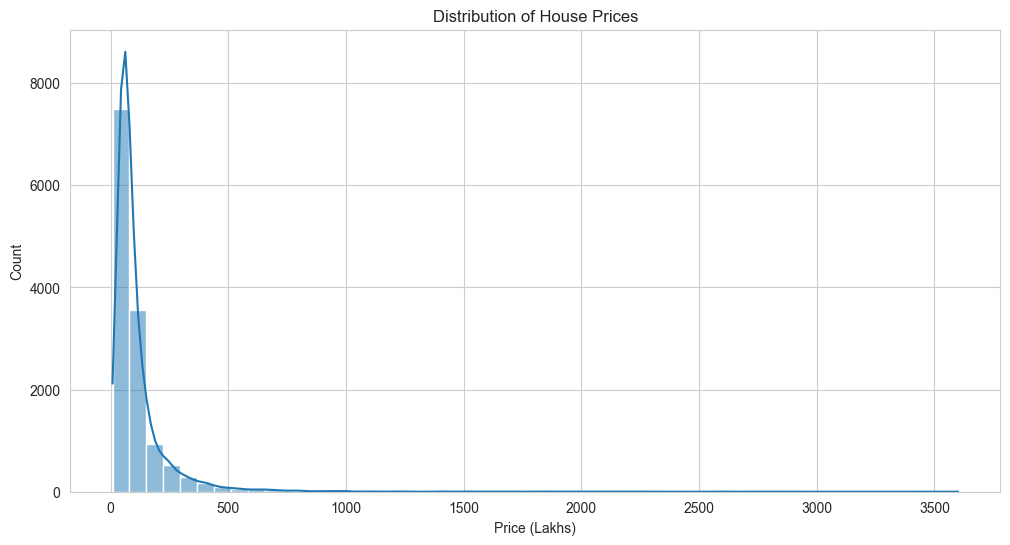

In [9]:
#Histoplot
plt.figure(figsize=(12, 6))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Count")
plt.show()

- right skewed distribution
- clear outliers are present
- outlier removal is needed

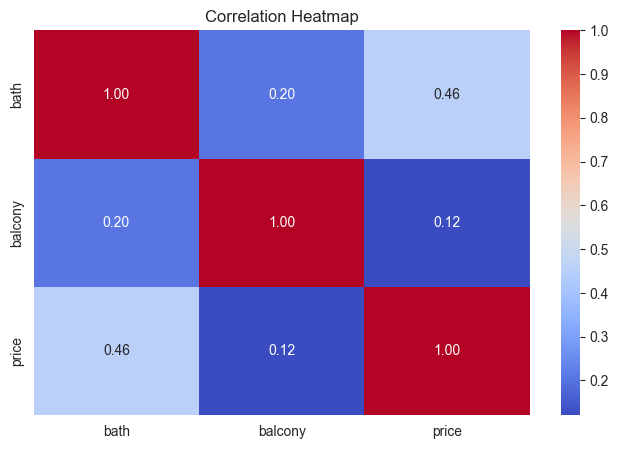

In [10]:
#correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df[["bath", "balcony", "price"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

- bath vs price = 0.46 moderatepositive correlation, more bathrooms = higher price
- balcony vs price = 0.12 very weak correlation 

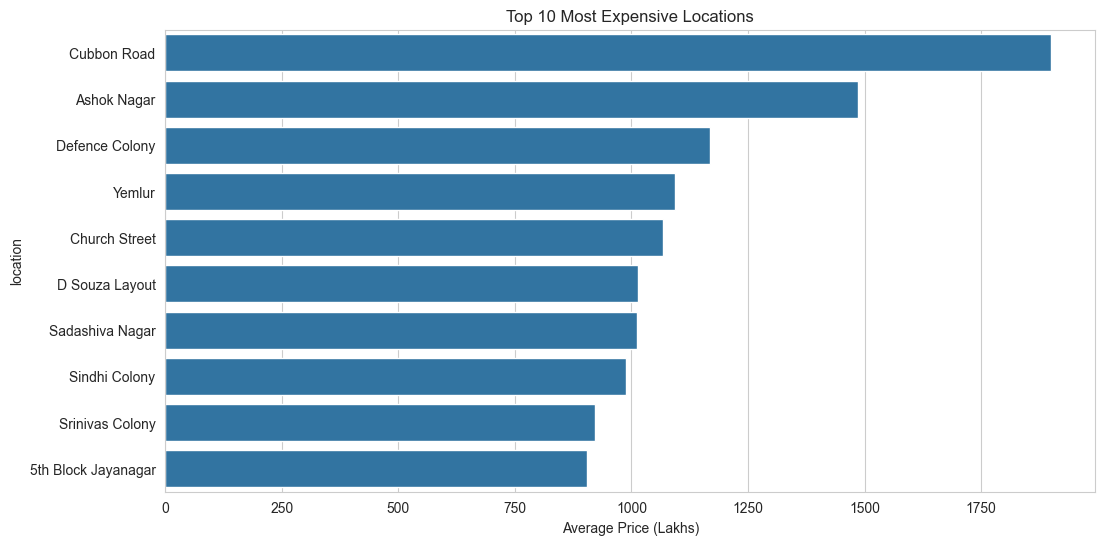

In [11]:
#top 10 locations
top_locations = df.groupby("location")["price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top 10 Most Expensive Locations")
plt.xlabel("Average Price (Lakhs)")
plt.show()

- cubbon road is the most expensive at ~1900 lakhs average
- all top 10 locations are average above 900 lakhs


In [13]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()

# Title
pdf.set_font("Helvetica", "B", 20)
pdf.cell(0, 15, "Bengaluru House Price - EDA Report", ln=True, align="C")
pdf.ln(5)

# Line
pdf.set_draw_color(200, 200, 200)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(8)

# Dataset Overview
pdf.set_font("Helvetica", "B", 14)
pdf.cell(0, 10, "1. Dataset Overview", ln=True)
pdf.set_font("Helvetica", "", 11)
pdf.cell(0, 8, f"Total Rows: 13,320", ln=True)
pdf.cell(0, 8, f"Total Columns: 9", ln=True)
pdf.cell(0, 8, f"Duplicate Rows: 0", ln=True)
pdf.ln(5)

# Missing Values
pdf.set_font("Helvetica", "B", 14)
pdf.cell(0, 10, "2. Missing Values", ln=True)
pdf.set_font("Helvetica", "", 11)
missing = df.isnull().sum()
for col, val in missing.items():
    pdf.cell(0, 8, f"  {col}: {val} missing ({round(val/len(df)*100, 2)}%)", ln=True)
pdf.ln(5)

# Data Types
pdf.set_font("Helvetica", "B", 14)
pdf.cell(0, 10, "3. Data Types", ln=True)
pdf.set_font("Helvetica", "", 11)
for col, dtype in df.dtypes.items():
    pdf.cell(0, 8, f"  {col}: {dtype}", ln=True)
pdf.ln(5)

# Basic Statistics
pdf.set_font("Helvetica", "B", 14)
pdf.cell(0, 10, "4. Basic Statistics", ln=True)
pdf.set_font("Helvetica", "", 11)
pdf.cell(0, 8, f"  Average Price: 112.57 Lakhs", ln=True)
pdf.cell(0, 8, f"  Min Price: 8 Lakhs", ln=True)
pdf.cell(0, 8, f"  Max Price: 3600 Lakhs", ln=True)
pdf.cell(0, 8, f"  Average Bathrooms: 2.69", ln=True)
pdf.cell(0, 8, f"  Max Bathrooms: 40 (outlier)", ln=True)
pdf.ln(5)

# Key Observations
pdf.set_font("Helvetica", "B", 14)
pdf.cell(0, 10, "5. Key Observations", ln=True)
pdf.set_font("Helvetica", "", 11)
observations = [
    "society column has 41% missing values - will be dropped",
    "total_sqft is string type - contains ranges like 1000-1200",
    "size column is inconsistent - 2 BHK and 2 Bedroom mean same thing",
    "Price distribution is right skewed - outliers present",
    "1305 unique locations - needs grouping for ML",
    "bath has outlier of 40 - unrealistic",
    "Cubbon Road is most expensive location at ~1900 lakhs average",
    "bath has 0.46 correlation with price",
    "balcony has only 0.12 correlation with price"
]
for obs in observations:
    pdf.cell(0, 8, f"  - {obs}", ln=True)
pdf.ln(5)

# Unique Values
pdf.set_font("Helvetica", "B", 14)
pdf.cell(0, 10, "6. Unique Values", ln=True)
pdf.set_font("Helvetica", "", 11)
pdf.cell(0, 8, f"  Unique Locations: 1305", ln=True)
pdf.cell(0, 8, f"  Unique Area Types: 4", ln=True)
pdf.cell(0, 8, f"  Unique Sizes: 31", ln=True)
pdf.ln(5)

# Save
pdf.output(r"C:\Users\HP\Desktop\RealEstatePricePrediction\reports\eda_report.pdf")
print("EDA report saved successfully!")

EDA report saved successfully!


C:\Users\HP\AppData\Local\Temp\ipykernel_1692\1751221989.py:8: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 15, "Bengaluru House Price - EDA Report", ln=True, align="C")
C:\Users\HP\AppData\Local\Temp\ipykernel_1692\1751221989.py:18: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, "1. Dataset Overview", ln=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_1692\1751221989.py:20: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, f"Total Rows: 13,320", ln=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_1692\1751221989.py:21: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, f"Total Columns: 9", ln=True)
C:\Users\HP\App